In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.inspection import PartialDependenceDisplay

In [3]:
train = pd.read_csv("data/playground-series-s3e1/train.csv")
test = pd.read_csv("data/playground-series-s3e1/test.csv")
sample_sub = pd.read_csv("data/playground-series-s3e1/sample_submission.csv")
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample submission shape:", sample_sub.shape)
print(train.isna().sum())
print("The first few features of the train csv file")
print(train.head())
print("The first few features of the test csv file")
print(test.head())

Train shape: (37137, 10)
Test shape: (24759, 9)
Sample submission shape: (24759, 2)
id             0
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64
The first few features of the train csv file
   id  MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0   0  2.3859      15.0  3.827160   1.112100      1280.0  2.486989     34.60   
1   1  3.7188      17.0  6.013373   1.054217      1504.0  3.813084     38.69   
2   2  4.7750      27.0  6.535604   1.103175      1061.0  2.464602     34.71   
3   3  2.4138      16.0  3.350203   0.965432      1255.0  2.089286     32.66   
4   4  3.7500      52.0  4.284404   1.069246      1793.0  1.604790     37.80   

   Longitude  MedHouseVal  
0    -120.12        0.980  
1    -121.22        0.946  
2    -120.45        1.576  
3    -117.09        1.336  
4    -122.41        4.500  
The first few features of the test csv 

count    37137.000000
mean         2.079751
std          1.158571
min          0.149990
25%          1.208000
50%          1.808000
75%          2.660000
max          5.000010
Name: MedHouseVal, dtype: float64


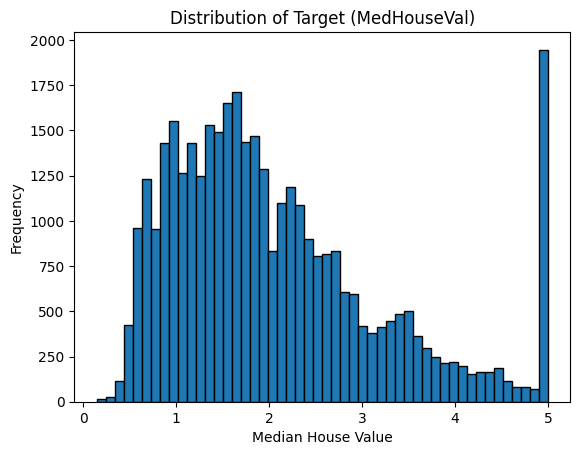

                id        MedInc      HouseAge      AveRooms     AveBedrms  \
count  37137.00000  37137.000000  37137.000000  37137.000000  37137.000000   
mean   18568.00000      3.851029     26.057005      5.163124      1.062204   
std    10720.67281      1.803167     12.158221      1.206242      0.096490   
min        0.00000      0.499900      2.000000      0.851064      0.500000   
25%     9284.00000      2.602300     17.000000      4.357522      1.020305   
50%    18568.00000      3.515600     25.000000      5.068611      1.054545   
75%    27852.00000      4.699700     35.000000      5.858597      1.088825   
max    37136.00000     15.000100     52.000000     28.837607      5.873181   

         Population      AveOccup      Latitude     Longitude  
count  37137.000000  37137.000000  37137.000000  37137.000000  
mean    1660.778919      2.831243     35.570030   -119.554329  
std     1302.469608      2.702413      2.083179      1.974028  
min        3.000000      0.950000     32.

In [4]:
# Step 2A: Target stats
print(train["MedHouseVal"].describe())

# Step 2B: Target distribution
plt.hist(train["MedHouseVal"], bins=50, edgecolor='k')
plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.title("Distribution of Target (MedHouseVal)")
plt.show()

# Step 2C: Feature summaries
print(train.drop(columns=["MedHouseVal"]).describe())


In [6]:
corr_target = train.corr()["MedHouseVal"].sort_values(ascending=False)
print("Correlation of features with target (MedHouseVal):")
print(corr_target)

Correlation of features with target (MedHouseVal):
MedHouseVal    1.000000
MedInc         0.701925
AveRooms       0.366727
HouseAge       0.103210
id            -0.001358
Population    -0.038479
AveOccup      -0.048475
Longitude     -0.056742
AveBedrms     -0.067487
Latitude      -0.116499
Name: MedHouseVal, dtype: float64


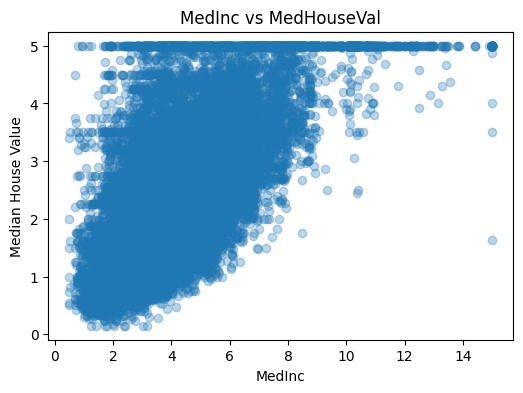

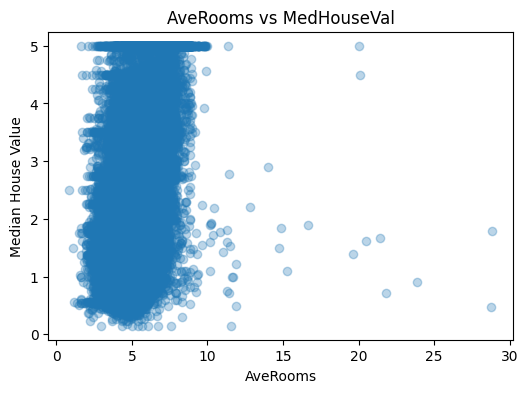

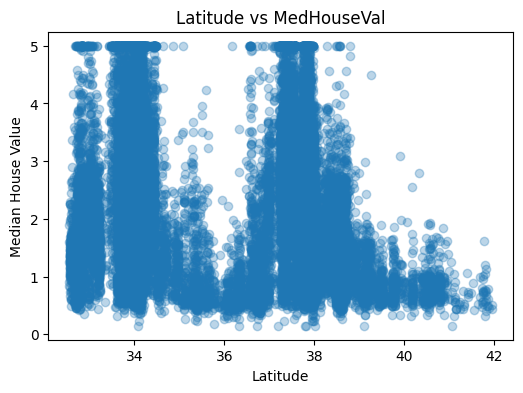

In [7]:
# Scatter plots vs target
features_to_plot = ["MedInc", "AveRooms", "Latitude"]

for feat in features_to_plot:
    plt.figure(figsize=(6,4))
    plt.scatter(train[feat], train["MedHouseVal"], alpha=0.3)
    plt.xlabel(feat)
    plt.ylabel("Median House Value")
    plt.title(f"{feat} vs MedHouseVal")
    plt.show()

In [ ]:
X = train.drop(columns=["MedHouseVal", "id"])
Y = train["MedHouseVal"]

X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=42)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(X_train)
x_val_scaled = scaler.transform(X_val)


models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01, max_iter=10000)
}
print("Training and evaluating models...")
print(models)
results = {}
for name, model in models.items():
    model.fit(x_train_scaled, Y_train)
    preds = model.predict(x_val_scaled)
    rmse = np.sqrt(mean_squared_error(Y_val, preds))
    results[name] = (rmse, model.coef_)
    print(f"{name} RMSE: {rmse:.4f}")

coef_df = pd.DataFrame({
    name: coef for name, (rmse, coef) in results.items()
}, index=X.columns)
print("Model Coefficients:")
print(coef_df)

Training and evaluating models...
{'Linear': LinearRegression(), 'Ridge': Ridge(), 'Lasso': Lasso(alpha=0.01, max_iter=10000)}
Linear RMSE: 0.7482
Ridge RMSE: 0.7482
Lasso RMSE: 0.7509
Model Coefficients:
              Linear     Ridge     Lasso
MedInc      0.879572  0.879603  0.870001
HouseAge    0.104944  0.104976  0.109977
AveRooms   -0.185927 -0.185937 -0.165639
AveBedrms   0.099935  0.099918  0.079154
Population -0.019086 -0.019079 -0.007935
AveOccup   -0.040765 -0.040765 -0.032237
Latitude   -0.846375 -0.845873 -0.685471
Longitude  -0.828735 -0.828233 -0.666800


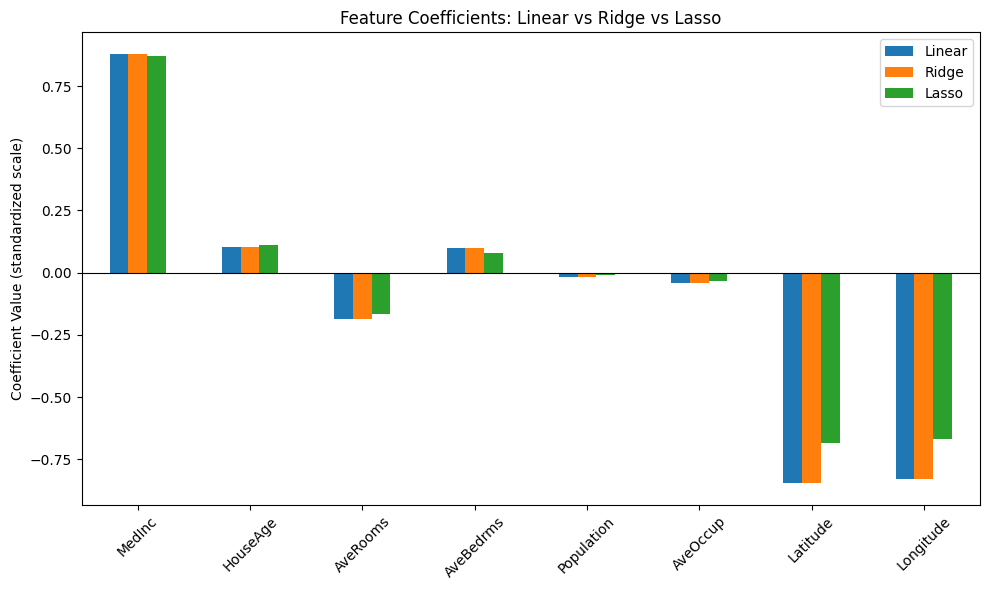

In [15]:
coef_df.plot(kind="bar", figsize=(10,6))
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Feature Coefficients: Linear vs Ridge vs Lasso")
plt.ylabel("Coefficient Value (standardized scale)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Depth 2: Train RMSE = 0.8406, Val RMSE = 0.8638
Depth 5: Train RMSE = 0.7155, Val RMSE = 0.7503
Depth 10: Train RMSE = 0.5502, Val RMSE = 0.7000
Depth 20: Train RMSE = 0.1572, Val RMSE = 0.8312
Depth None: Train RMSE = 0.0000, Val RMSE = 0.8420


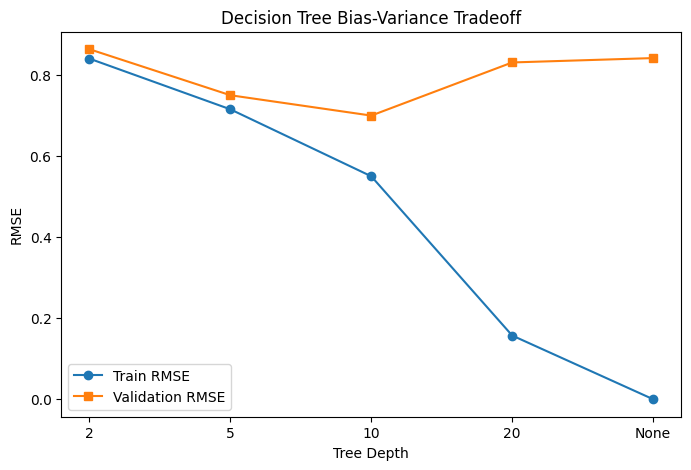


Feature importances (depth=5):
MedInc        0.821873
AveOccup      0.094221
Latitude      0.031698
AveRooms      0.021668
Longitude     0.017023
HouseAge      0.013517
AveBedrms     0.000000
Population    0.000000
dtype: float64


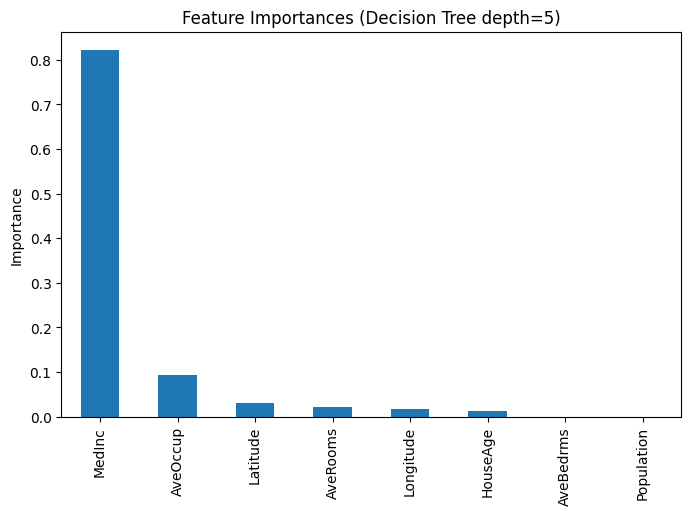

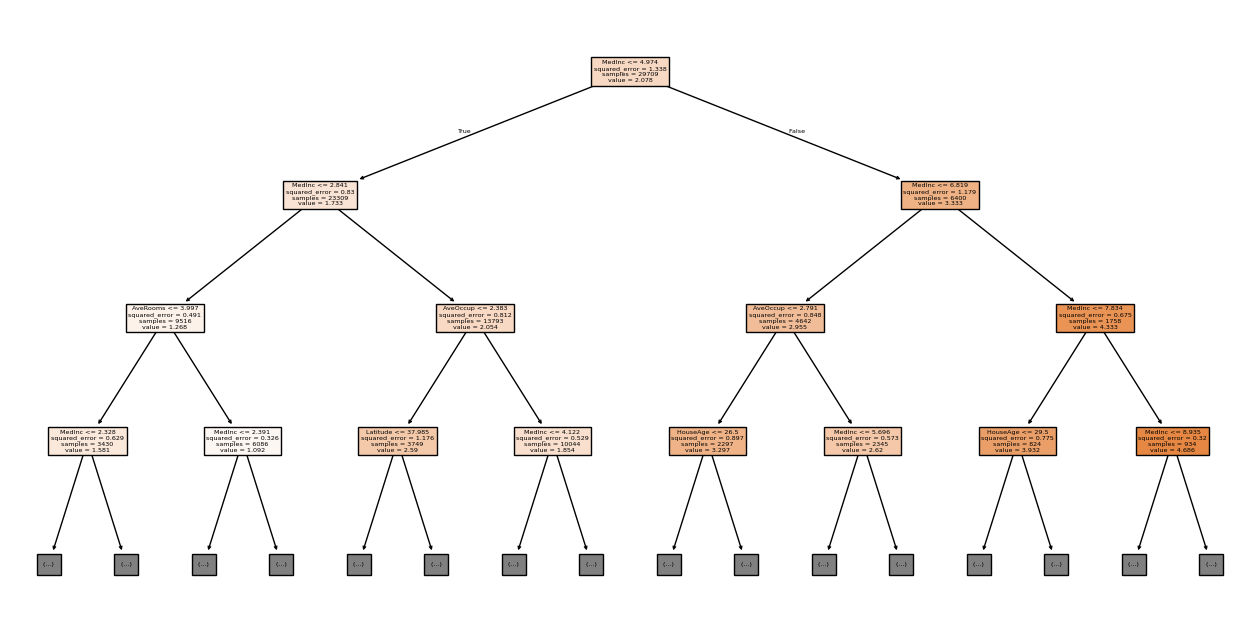

In [20]:
depths = [2, 5, 10, 20, None]  # None = unlimited depth
rmse_results = []

for d in depths:
    tree = DecisionTreeRegressor(max_depth=d, random_state=42)
    tree.fit(X_train, Y_train)

    train_preds = tree.predict(X_train)
    val_preds = tree.predict(X_val)

    train_rmse = np.sqrt(mean_squared_error(Y_train, train_preds))
    val_rmse = np.sqrt(mean_squared_error(Y_val, val_preds))

    rmse_results.append((d, train_rmse, val_rmse))
    print(f"Depth {d}: Train RMSE = {train_rmse:.4f}, Val RMSE = {val_rmse:.4f}")

# --- RMSE plot ---
depth_labels = [str(d) for d, _, _ in rmse_results]
train_scores = [tr for _, tr, _ in rmse_results]
val_scores = [vr for _, _, vr in rmse_results]

plt.figure(figsize=(8,5))
plt.plot(depth_labels, train_scores, marker='o', label="Train RMSE")
plt.plot(depth_labels, val_scores, marker='s', label="Validation RMSE")
plt.xlabel("Tree Depth")
plt.ylabel("RMSE")
plt.title("Decision Tree Bias-Variance Tradeoff")
plt.legend()
plt.show()

# --- Feature importances for depth=5 (example) ---
best_depth = 5
tree = DecisionTreeRegressor(max_depth=best_depth, random_state=42)
tree.fit(X_train, Y_train)

importances = pd.Series(tree.feature_importances_, index=X.columns).sort_values(ascending=False)
print(f"\nFeature importances (depth={best_depth}):")
print(importances)

# Plot feature importances
plt.figure(figsize=(8,5))
importances.plot(kind="bar")
plt.title(f"Feature Importances (Decision Tree depth={best_depth})")
plt.ylabel("Importance")
plt.show()

# --- Optional: Visualize tree structure ---
plt.figure(figsize=(16,8))
plot_tree(tree, feature_names=X.columns, filled=True, max_depth=3)  # show only top 3 levels
plt.show()

In [27]:
# Grid of parameters
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 20, None],
    "max_features": ["sqrt", "auto"]  # "auto"=all in sklearn >=1.1
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,  # 5 - fold CV
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, Y_train)

print("Best Params:", grid_search.best_params_)
print("Best CV RMSE:", -grid_search.best_score_)

# Evaluate best model on validation set
best_rf = grid_search.best_estimator_
val_preds = best_rf.predict(X_val)
val_rmse = np.sqrt(mean_squared_error(Y_val, val_preds))
print("Validation RMSE of best RF:", val_rmse)

# Feature importances
importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nBest RF Feature Importances:")
print(importances)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


d:\trash_stuff\kaggle_playground_s3_ep1\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
60 fits failed out of a total of 120.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "d:\trash_stuff\kaggle_playground_s3_ep1\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\trash_stuff\kaggle_playground_s3_ep1\.venv\Lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "d:\trash_stuff\kaggle_playgroun

Best Params: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 300}
Best CV RMSE: 0.5839568244750011
Validation RMSE of best RF: 0.609760196611492

Best RF Feature Importances:
MedInc        0.366064
AveRooms      0.145557
Longitude     0.131514
Latitude      0.123204
AveOccup      0.102814
HouseAge      0.049035
Population    0.041329
AveBedrms     0.040482
dtype: float64


In [30]:
# Generate polynomial features (degree=2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_val_poly = poly.transform(X_val)

print("Original features:", X_train.shape[1])
print("Polynomial features (degree=2):", X_train_poly.shape[1])

# Fit Ridge regression on polynomial features
poly_ridge = Ridge(alpha=1.0)  # regularization prevents wild coefficients
poly_ridge.fit(X_train_poly, Y_train)

# Predictions
train_preds = poly_ridge.predict(X_train_poly)
val_preds = poly_ridge.predict(X_val_poly)

# RMSE
train_rmse = np.sqrt(mean_squared_error(Y_train, train_preds))
val_rmse = np.sqrt(mean_squared_error(Y_val, val_preds))

print(f"Polynomial Ridge (deg=2) Train RMSE: {train_rmse:.4f}")
print(f"Polynomial Ridge (deg=2) Val RMSE:   {val_rmse:.4f}")

Original features: 8
Polynomial features (degree=2): 44
Polynomial Ridge (deg=2) Train RMSE: 0.6658
Polynomial Ridge (deg=2) Val RMSE:   0.6977


d:\trash_stuff\kaggle_playground_s3_ep1\.venv\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=9.23308e-20): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


In [32]:
# DMatrix is XGBoost's optimized data structure
dtrain = xgb.DMatrix(X_train, label=Y_train)
dval = xgb.DMatrix(X_val, label=Y_val)

# Params for regression
params = {
    "objective": "reg:squarederror",  # regression task
    "eval_metric": "rmse",
    "tree_method": "hist",            # change to "gpu_hist" if GPU available
    "learning_rate": 0.1,
    "max_depth": 6,
    "subsample": 0.8,                 # row sampling
    "colsample_bytree": 0.8           # feature sampling
}

# Train with early stopping
evals = [(dtrain, "train"), (dval, "val")]
xgb_model = xgb.train(
    params,
    dtrain,
    num_boost_round=1000,
    evals=evals,
    early_stopping_rounds=50,
    verbose_eval=50
)

# Predict
val_preds = xgb_model.predict(dval)
val_rmse = np.sqrt(mean_squared_error(Y_val, val_preds))
print("XGBoost Validation RMSE:", val_rmse)

[0]	train-rmse:1.09966	val-rmse:1.11007
[50]	train-rmse:0.53834	val-rmse:0.60514
[100]	train-rmse:0.50239	val-rmse:0.59526
[150]	train-rmse:0.47853	val-rmse:0.59375
[200]	train-rmse:0.45868	val-rmse:0.59314
[245]	train-rmse:0.44175	val-rmse:0.59384
XGBoost Validation RMSE: 0.5938361914958594


In [36]:
# Define model
xgb_reg = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",     # or "gpu_hist" if GPU available
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

# Hyperparameter grid
param_grid = {
    "max_depth": [4, 6, 8],
    "learning_rate": [0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=xgb_reg,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    verbose=2
)

grid_search.fit(X_train, Y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV RMSE:", -grid_search.best_score_)

# Evaluate best model on validation set
best_xgb = grid_search.best_estimator_
val_preds = best_xgb.predict(X_val)
val_rmse = np.sqrt(mean_squared_error(Y_val, val_preds))
print("Validation RMSE of best XGB:", val_rmse)

Fitting 5 folds for each of 81 candidates, totalling 405 fits
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=4, subsample=0.7; total time=   0.5s
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=4, subsample=0.7; total time=   0.2s
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=4, subsample=0.7; total time=   0.3s
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=4, subsample=0.7; total time=   0.2s
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=4, subsample=0.7; total time=   0.2s
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=4, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=4, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=4, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=4, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_d

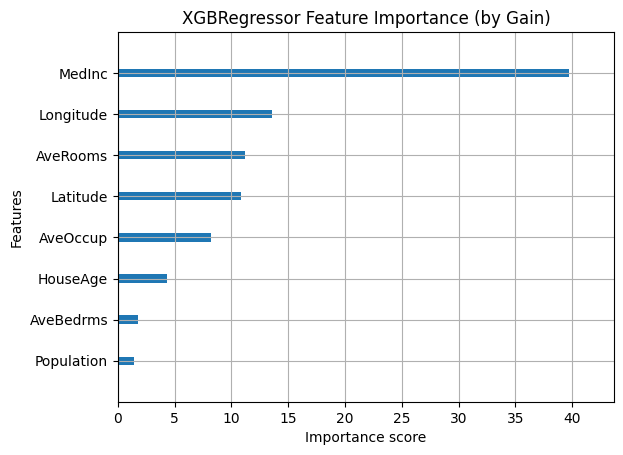

In [ ]:
# Gain-based feature importance
xgb.plot_importance(best_xgb, importance_type="gain", show_values=False)
plt.title("XGBRegressor Feature Importance (by Gain)")
plt.show()

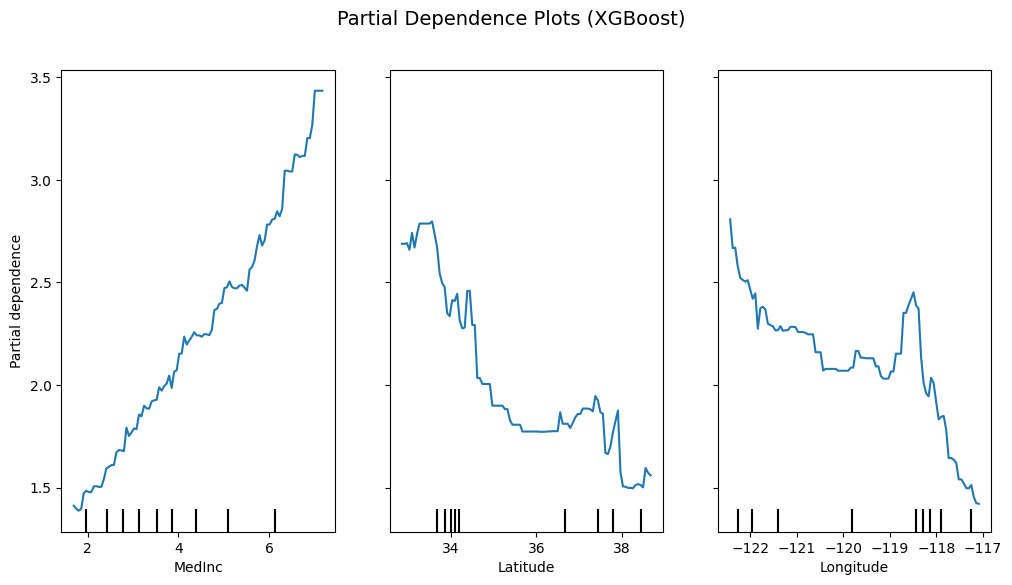

In [43]:
# Features to plot
features = ["MedInc", "Latitude", "Longitude"]

# Partial Dependence Plots
fig, ax = plt.subplots(figsize=(12, 6))
PartialDependenceDisplay.from_estimator(best_xgb, X_val, features, ax=ax)
plt.suptitle("Partial Dependence Plots (XGBoost)", fontsize=14)
plt.show()

In [53]:
# Transform target
y_train_log = np.log1p(Y_train)
y_val_log = np.log1p(Y_val)

# Convert to DMatrix
dtrain_log = xgb.DMatrix(X_train, label=y_train_log)
dval_log = xgb.DMatrix(X_val, label=y_val_log)

# Params (same best params as before)
params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "tree_method": "gpu_hist",   # use "hist" if no GPU
    "learning_rate": 0.05,
    "max_depth": 6,
    "subsample": 1.0,
    "colsample_bytree": 0.7
}

evals = [(dtrain_log, "train"), (dval_log, "val")]

# Train with early stopping
xgb_log = xgb.train(
    params=params,
    dtrain=dtrain_log,
    num_boost_round=500,
    evals=evals,
    early_stopping_rounds=50,
    verbose_eval=50
)

# Predict on val (then invert log)
val_preds_log = xgb_log.predict(dval_log)
val_preds = np.expm1(val_preds_log)

# Compute RMSE in original scale
val_rmse_log = np.sqrt(mean_squared_error(Y_val, val_preds))
print("Validation RMSE with log-transformed target:", val_rmse_log)

d:\trash_stuff\kaggle_playground_s3_ep1\.venv\Lib\site-packages\xgboost\callback.py:386: UserWarning: [20:51:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  self.starting_round = model.num_boosted_rounds()


[0]	train-rmse:0.34550	val-rmse:0.34567
[50]	train-rmse:0.17769	val-rmse:0.18874
[100]	train-rmse:0.16083	val-rmse:0.17728
[150]	train-rmse:0.15544	val-rmse:0.17547
[200]	train-rmse:0.15154	val-rmse:0.17453
[250]	train-rmse:0.14815	val-rmse:0.17394
[300]	train-rmse:0.14528	val-rmse:0.17371
[350]	train-rmse:0.14262	val-rmse:0.17352
[400]	train-rmse:0.14007	val-rmse:0.17337
[450]	train-rmse:0.13784	val-rmse:0.17330
[499]	train-rmse:0.13576	val-rmse:0.17317
Validation RMSE with log-transformed target: 0.5966661859515331


d:\trash_stuff\kaggle_playground_s3_ep1\.venv\Lib\site-packages\xgboost\core.py:729: UserWarning: [20:52:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  return func(**kwargs)


In [55]:
# Drop id column for predictions
X_test = test.drop(columns=["id"])

# Predict directly with sklearn API model
test_preds = best_xgb.predict(X_test)

# Fill into sample_submission
submission = sample_sub.copy()
submission["MedHouseVal"] = test_preds

# Save to CSV
submission.to_csv("data/playground-series-s3e1/submission.csv", index=False)
print("submission.csv created with shape:", submission.shape)

submission.csv created with shape: (24759, 2)
